# Problem 9.3

**Integrated Energy Grids**

**Build the model described in Problem 3.2 in PyPSA (i.e. the problem 9.2 but not including the CCGT generator with exogenous capacity).**

**a) Solve the problem for different CO$_2$ values ranging from 5 MtCO2/year to zero. Plot the total system cost and the required CO$_2$ prices as a function of the emissions allowance.**

**b) Show that setting a CO$_2$ limit is equivalent to a carbon tax. Use your results in a) for the appropriate carbon tax. Compare total system costs, emissions, and cost for carbon.**


:::{note}
If you have not yet set up Python on your computer, you can execute this tutorial in your browser via [Google Colab](https://colab.research.google.com/). Click on the rocket in the top right corner and launch "Colab". If that doesn't work download the `.ipynb` file and import it in [Google Colab](https://colab.research.google.com/).

Then install `pandas` and `numpy` by executing the following command in a Jupyter cell at the top of the notebook.

```sh
!pip install pandas pypsa
```
:::

:::{note}
See also https://model.energy.
:::

In this exercise, we want to build a replica of [model.energy](https://model.energy). This tool calculates the cost of meeting a constant electricity demand from a combination of wind power, solar power and storage for different regions of the world. We deviate from [model.energy](https://model.energy) by including electricity demand profiles rather than a constant electricity demand. 

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

Set parameter Username
Set parameter LicenseID to value 2767832
Academic license - for non-commercial use only - expires 2027-01-20


## Prerequisites: handling technology data and costs

We maintain a database (https://github.com/PyPSA/technology-data/tree/v0.11.0, v0.11.0) which collects assumptions and projections for energy system technologies (such as costs, efficiencies, lifetimes, etc.) for given years, which we can load into a `pandas.DataFrame`. This requires some pre-processing to load (e.g. converting units, setting defaults, re-arranging dimensions):

In [2]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [3]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

Let's also write a small utility function that calculates the **annuity** to annualise investment costs. The formula is

$$
a(r, n) = \frac{r}{1-(1+r)^{-n}}
$$
where $r$ is the discount rate and $n$ is the lifetime.

In [4]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

In [5]:
annuity(0.07, 20)

0.09439292574325567

Based on this, we can calculate the marginal generation costs (€/MWh):

In [6]:
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

and the annualised investment costs (`capital_cost` in PyPSA terms, €/MW/a):

In [7]:
annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

In [8]:
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

Now we can for example read the capital and marginal cost of onshore wind and solar, or the emissions factors of the carrier gas used in and OCGT

In [9]:
costs.at["onwind", "capital_cost"] #EUR/MW/a

np.float64(101644.12332388277)

In [10]:
costs.at["solar", "capital_cost"] #EUR/MW/a

np.float64(51346.82981964593)

In [11]:
costs.at["OCGT", "CO2 intensity"] #tCO2/MWh_th

np.float64(0.198)

## Retrieving time series data

In this example, wind data from [https://zenodo.org/record/3253876#.XSiVOEdS8l0](https://zenodo.org/record/3253876#.XSiVOEdS8l0) and solar PV data from [https://zenodo.org/record/2613651#.X0kbhDVS-uV](https://zenodo.org/record/3253876#.XSiVOEdS8l0) is used. The data is downloaded in csv format and saved in the 'data' folder.
The Pandas package is used as a convenient way of managing the datasets.

For convenience, the column including date information is converted into Datetime and set as index

In [12]:
data_solar = pd.read_csv('data/pv_optimal.csv',sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv',sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

data_el = pd.read_csv('data/electricity_demand.csv',sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

The data format can now be analyzed using the .head() function to show the first lines of the data set

In [13]:
data_solar.head()

,utc_time,AUT,BEL,BGR,BIH,CHE,CYP,CZE,DEU,DNK,...,MLT,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
utc_time,,,,,,,,,,,,,,,,,,,,,
1979-01-01 00:00:00+00:00,1979-01-01T00:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 01:00:00+00:00,1979-01-01T01:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 02:00:00+00:00,1979-01-01T02:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 03:00:00+00:00,1979-01-01T03:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 04:00:00+00:00,1979-01-01T04:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We will use timeseries for Portugal in this excercise

In [14]:
country = 'PRT'

### Joint capacity and dispatch optimisation

For building the model, we start again by initialising an empty network, adding the snapshots, and the electricity bus.

In [15]:
n = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

n.set_snapshots(hours_in_2015.values)

n.add("Bus",
      "electricity")

n.snapshots

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               ...
               '2015-12-31 14:00:00', '2015-12-31 15:00:00',
               '2015-12-31 16:00:00', '2015-12-31 17:00:00',
               '2015-12-31 18:00:00', '2015-12-31 19:00:00',
               '2015-12-31 20:00:00', '2015-12-31 21:00:00',
               '2015-12-31 22:00:00', '2015-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)

We add all the technologies we are going to include as carriers. 

In [16]:
carriers = [
    "onwind",
    "solar",
    "OCGT",
    "battery storage",
]

n.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "gold", "indianred", "brown"],
    co2_emissions=[costs.at[c, "CO2 intensity"] for c in carriers],
)

Next, we add the demand time series to the model.

In [17]:
# add load to the bus
n.add("Load",
      "demand",
      bus="electricity",
      p_set=data_el[country].values)

Let's have a check whether the data was read-in correctly.

<Axes: xlabel='snapshot', ylabel='MW'>

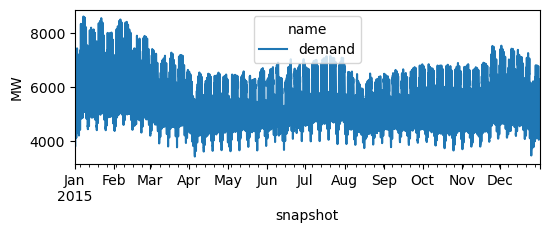

In [18]:
n.loads_t.p_set.plot(figsize=(6, 2), ylabel="MW")

We add now the generators and set up their capacities to be extendable so that they can be optimized together with the dispatch time series. For the wind and solar generator, we need to indicate the capacity factor or maximum power per unit 'p_max_pu'

In [19]:
n.add(
    "Generator",
    "OCGT",
    bus="electricity",
    carrier="OCGT",
    capital_cost=costs.at["OCGT", "capital_cost"],
    marginal_cost=costs.at["OCGT", "marginal_cost"],
    efficiency=costs.at["OCGT", "efficiency"],
    p_nom_extendable=True,
)

CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "onwind",
        bus="electricity",
        carrier="onwind",
        p_max_pu=CF_wind.values,
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )

CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "solar",
        bus="electricity",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )

So let's make sure the capacity factors are read-in correctly.

<Axes: xlabel='snapshot', ylabel='CF'>

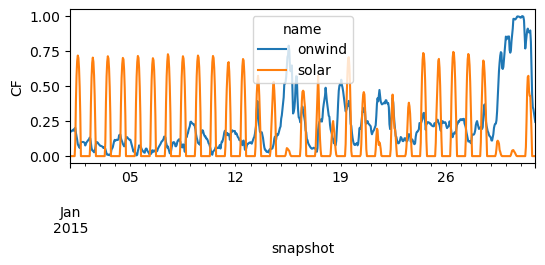

In [20]:
n.generators_t.p_max_pu.loc["2015-01"].plot(figsize=(6, 2), ylabel="CF")

We add the battery storage, assuming a fixed energy-to-power ratio of 2 hours, i.e. if fully charged, the battery can discharge at full capacity for 2 hours. 

For the capital cost, we have to factor in both the capacity and energy cost of the storage. 

We include the charging and discharging efficiencies we enforce a cyclic state-of-charge condition, i.e. the state of charge at the beginning of the optimisation period must equal the final state of charge.

In [21]:
n.add(
    "StorageUnit",
    "battery storage",
    bus="electricity",
    carrier="battery storage",
    max_hours=2,
    capital_cost=costs.at["battery inverter", "capital_cost"]
    + 2 * costs.at["battery storage", "capital_cost"],
    efficiency_store=costs.at["battery inverter", "efficiency"],
    efficiency_dispatch=costs.at["battery inverter", "efficiency"],
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)

### Model Run

Before solving the problem we add a CO$_2$ emission limit as global constraint:

In [22]:
n.add(
    "GlobalConstraint",
    "CO2Limit",
    carrier_attribute="co2_emissions",
    sense="<=",
    constant=5000000, #5MtCO2
)

We can already solved the model using the open-solver "highs" or the commercial solver "gurobi" with the academic license

In [23]:
n.optimize(solver_name="gurobi")

Index(['electricity'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 660.73it/s]
INFO:linopy.io: Writing time: 0.17s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2767832


INFO:gurobipy:Set parameter LicenseID to value 2767832


...

Solved in 7345 iterations and 2.50 seconds (5.27 work units)


INFO:gurobipy:Solved in 7345 iterations and 2.50 seconds (5.27 work units)


Optimal objective  3.472266385e+09


INFO:gurobipy:Optimal objective  3.472266385e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52564 primals, 122645 duals
Objective: 3.47e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

Now, we can look at the results and evaluate the total system cost (in billion Euros per year)

In [24]:
print(n.objective / 1e9)
n.global_constraints

3.4722663853160163


,type,investment_period,bus,carrier_attribute,sense,constant,mu
name,,,,,,,
CO2Limit,primary_energy,NaN,,co2_emissions,<=,5000000.0,-106.265723


**a) Solve the problem for different CO$_2$ values ranging from 5 MtCO2/year to zero. Plot the total system cost and the required CO$_2$ prices as a function of the emissions allowance.**

In [25]:
sensitivity = {}
co2_price = pd.Series()
def system_cost(n):
    tsc = n.statistics.capex() + n.statistics.opex()
    return tsc.droplevel(0).div(1e6)  # million €/a
    
for co2 in [5, 4, 3, 2, 1, 0]:
    n.global_constraints.loc["CO2Limit", "constant"] = co2 * 1e6
    n.optimize(solver_name="gurobi")
    sensitivity[co2] = system_cost(n)
    co2_price[co2] = -n.global_constraints.mu['CO2Limit']

Index(['electricity'], dtype='object', name='name')
Index(['0'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 588.01it/s]
INFO:linopy.io: Writing time: 0.16s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2767832


INFO:gurobipy:Set parameter LicenseID to value 2767832


...

INFO:gurobipy:


Solved in 4521 iterations and 0.64 seconds (0.80 work units)


INFO:gurobipy:Solved in 4521 iterations and 0.64 seconds (0.80 work units)


Optimal objective  6.607711978e+09


INFO:gurobipy:Optimal objective  6.607711978e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52564 primals, 122645 duals
Objective: 6.61e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


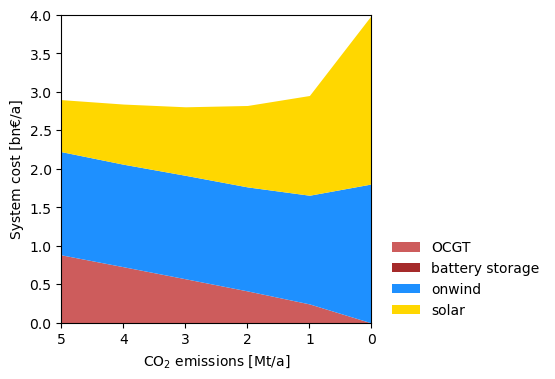

In [26]:
df = pd.DataFrame(sensitivity).T.div(1e3)  # billion Euro/a
df.plot.area(
    stacked=True,
    linewidth=0,
    color=df.columns.map(n.carriers.color),
    figsize=(4, 4),
    xlim=(0, 5),
    xlabel=r"CO$_2$ emissions [Mt/a]",
    ylabel="System cost [bn€/a]",
    ylim=(0, 4),
)
plt.legend(frameon=False, loc=(1.05, 0))
plt.gca().invert_xaxis()

In [27]:
co2_price

5      106.265723
4      132.095850
3      179.068159
2      270.257945
1      691.503196
0    29705.768984
dtype: float64

(0.0, 1000.0)

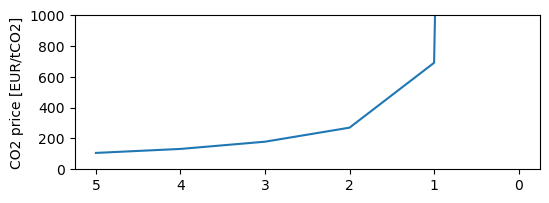

In [28]:
co2_price.plot(figsize=(6, 2), ylabel="CO2 price [EUR/tCO2]")
plt.gca().invert_xaxis()
plt.ylim([0,1000])

**b) Show that setting a CO$_2$ limit is equivalent to a carbon tax. Use your results from a) for the appropriate carbon taxes. Compare total system costs, emissions, and costs for carbon.**


In [29]:
n = pypsa.Network()

hours_in_2015 = pd.date_range("2015-01-01 00:00Z", "2015-12-31 23:00Z", freq="h")
n.set_snapshots(hours_in_2015.values)

n.add("Bus", "electricity")

carriers = ["onwind", "solar", "OCGT", "battery storage"]
n.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "gold", "indianred", "brown"],
    co2_emissions=[costs.at[c, "CO2 intensity"] for c in carriers],
)

n.add("Load", "demand", bus="electricity", p_set=data_el[country].values)

snapshot_cols = [hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]
for carrier, cf_data in [("onwind", data_wind), ("solar", data_solar)]:
    n.add(
        "Generator",
        carrier,
        bus="electricity",
        carrier=carrier,
        p_max_pu=cf_data[country][snapshot_cols].values,
        capital_cost=costs.at[carrier, "capital_cost"],
        marginal_cost=costs.at[carrier, "marginal_cost"],
        efficiency=costs.at[carrier, "efficiency"],
        p_nom_extendable=True,
    )

n.add(
    "StorageUnit",
    "battery storage",
    bus="electricity",
    carrier="battery storage",
    max_hours=2,
    capital_cost=(
        costs.at["battery inverter", "capital_cost"]
        + 2 * costs.at["battery storage", "capital_cost"]
    ),
    efficiency_store=costs.at["battery inverter", "efficiency"],
    efficiency_dispatch=costs.at["battery inverter", "efficiency"],
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)

In [30]:
# Compute marginal emissions of OCGT.

ocgt_emissions = costs.at["OCGT", "CO2 intensity"] / costs.at["OCGT", "efficiency"]  # tCO2/MWh_el

In [31]:
total_emissions = {}
tsc = {}
co2_cost = {}

for limit, price in co2_price.items():
    network = n.copy()
    network.add(
        "Generator",
        "OCGT",
        bus="electricity",
        carrier="OCGT",
        capital_cost=costs.at["OCGT", "capital_cost"],
        marginal_cost=costs.at["OCGT", "marginal_cost"] + price * ocgt_emissions,
        efficiency=costs.at["OCGT", "efficiency"],
        p_nom_extendable=True,
    )
    network.optimize(solver_name="gurobi", solver_options={"OutputFlag": 0})
    tsc[limit] = system_cost(network)

    supply_by_carrier = network.statistics.supply().groupby("carrier").sum()
    total_emissions[limit] = (
        supply_by_carrier.at["OCGT"] * ocgt_emissions
        if "OCGT" in supply_by_carrier.index
        else 0
    )
    co2_cost[limit] = price * total_emissions[limit]

Index(['electricity'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - OutputFlag: 0
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 455.75it/s]
INFO:linopy.io: Writing time: 0.19s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2767832


INFO:gurobipy:Set parameter LicenseID to value 2767832


...

INFO:gurobipy:Read LP format model from file /private/var/folders/zg/by4_k0616s98pw41wld9475c0000gp/T/linopy-problem-na7ts3tn.lp


Reading time = 0.13 seconds


INFO:gurobipy:Reading time = 0.13 seconds


obj: 122644 rows, 52564 columns, 232162 nonzeros


INFO:gurobipy:obj: 122644 rows, 52564 columns, 232162 nonzeros
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52564 primals, 122644 duals
Objective: 6.61e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


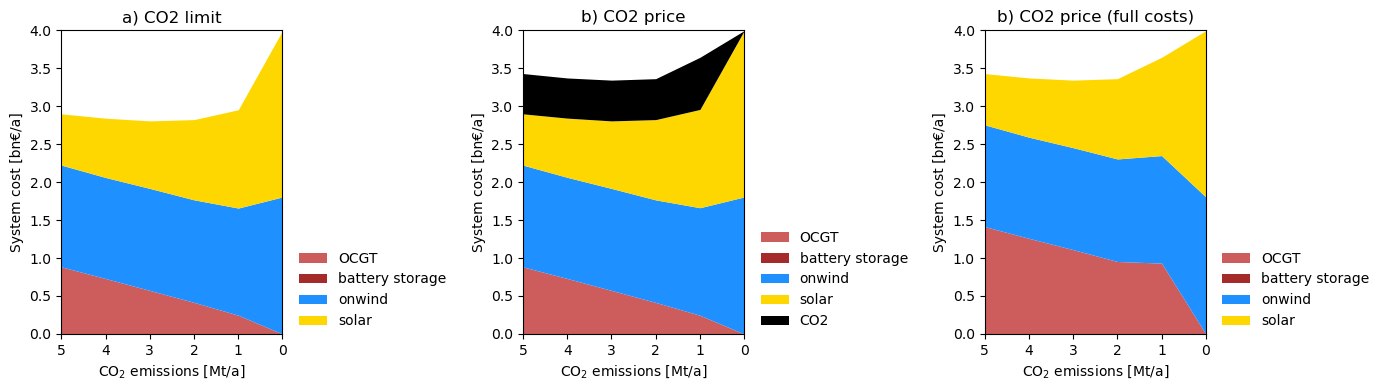

In [32]:
df_tsc = pd.DataFrame(tsc).T
df_co2 = pd.Series(co2_cost).div(1e6)  # bn€/a

# Separate CO2 cost from gas cost to compare a) and b).
cost_comparison = df_tsc.copy()
cost_comparison["CO2"] = df_co2
cost_comparison["OCGT"] = cost_comparison["OCGT"] - cost_comparison["CO2"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

shared_kwargs = dict(
    stacked=True,
    linewidth=0,
    xlim=(0, 5),
    xlabel=r"CO$_2$ emissions [Mt/a]",
    ylabel="System cost [bn€/a]",
    ylim=(0, 4),
)
legend_kwargs = dict(frameon=False, loc=(1.05, 0))

df.plot.area(
    **shared_kwargs,
    color=df.columns.map(n.carriers.color),
    ax=axes[0],
)
axes[0].legend(**legend_kwargs)
axes[0].invert_xaxis()
axes[0].set_title("a) CO2 limit")

cost_comparison.div(1e3).plot.area(
    **shared_kwargs,
    color=["indianred", "brown", "dodgerblue", "gold", "black"],
    ax=axes[1],
)
axes[1].set_title("b) CO2 price")
axes[1].legend(**legend_kwargs)
axes[1].invert_xaxis()

df_tsc.div(1e3).plot.area(
    **shared_kwargs,
    color=df_tsc.columns.map(network.carriers.color),
    ax=axes[2],
)
axes[2].set_title("b) CO2 price (full costs)")
axes[2].legend(**legend_kwargs)
axes[2].invert_xaxis()

plt.tight_layout()

In [33]:
total_emissions

{5: np.float64(4996470.728304001),
 4: np.float64(4005041.1373628783),
 3: np.float64(2999173.5590970735),
 2: np.float64(1996019.5443765367),
 1: np.float64(993436.695465366),
 0: 0}